# Tarea 3: Polars
**LEAD University** | Ciencia de Datos
Dataset: [100,000 Diabetes Clinical Dataset](https://www.kaggle.com/datasets/priyamchoksi/100000-diabetes-clinical-dataset) — Kaggle


In [1]:
# Instalar dependencias si es necesario
# !pip install polars scikit-learn xgboost lightgbm matplotlib seaborn dask[dataframe] psutil

In [2]:
import time
import warnings
import os
import psutil

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = 'diabetes_dataset.csv'  # ajustar ruta si es necesario
RANDOM_STATE = 42

print(f"Polars v{pl.__version__} | Pandas v{pd.__version__}")
print(f"CPU cores: {os.cpu_count()} | RAM: {psutil.virtual_memory().total / 1e9:.1f} GB")

Polars v1.41.2 | Pandas v3.0.3
CPU cores: 12 | RAM: 17.0 GB


## Parte 1: Análisis Exploratorio (EDA) con Polars

### 1.1 Carga y descripción del dataset

In [3]:
df = pl.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head(5)

Shape: (100000, 16)


year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
i64,str,f64,str,i64,i64,i64,i64,i64,i64,i64,str,f64,f64,i64,i64
2020,"""Female""",32.0,"""Alabama""",0,0,0,0,1,0,0,"""never""",27.32,5.0,100,0
2015,"""Female""",29.0,"""Alabama""",0,1,0,0,0,0,0,"""never""",19.95,5.0,90,0
2015,"""Male""",18.0,"""Alabama""",0,0,0,0,1,0,0,"""never""",23.76,4.8,160,0
2015,"""Male""",41.0,"""Alabama""",0,0,1,0,0,0,0,"""never""",27.32,4.0,159,0
2016,"""Female""",52.0,"""Alabama""",1,0,0,0,0,0,0,"""never""",23.75,6.5,90,0


In [4]:
# Tipos de datos
df.schema

Schema([('year', Int64),
        ('gender', String),
        ('age', Float64),
        ('location', String),
        ('race:AfricanAmerican', Int64),
        ('race:Asian', Int64),
        ('race:Caucasian', Int64),
        ('race:Hispanic', Int64),
        ('race:Other', Int64),
        ('hypertension', Int64),
        ('heart_disease', Int64),
        ('smoking_history', String),
        ('bmi', Float64),
        ('hbA1c_level', Float64),
        ('blood_glucose_level', Int64),
        ('diabetes', Int64)])

**Variables del dataset:**
- `year`: año del registro
- `gender`: sexo del paciente
- `age`: edad
- `location`: estado de EE.UU.
- `race:*` (5 cols): indicadores one-hot de etnia
- `hypertension`, `heart_disease`: condiciones previas (binario)
- `smoking_history`: historial de tabaquismo
- `bmi`: índice de masa corporal
- `hbA1c_level`: nivel de hemoglobina glicosilada
- `blood_glucose_level`: glucosa en sangre
- `diabetes`: variable objetivo (0 = no diabético, 1 = diabético)

## 1.2 Estadisticas Descriptivas

In [5]:
df.describe()

statistic,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
str,f64,str,f64,str,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64
"""count""",100000.0,"""100000""",100000.0,"""100000""",100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,"""100000""",100000.0,100000.0,100000.0,100000.0
"""null_count""",0.0,"""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0
"""mean""",2018.36082,null,41.885856,null,0.20223,0.20015,0.19876,0.19888,0.19998,0.07485,0.03942,null,27.320767,5.527507,138.05806,0.085
"""std""",1.345239,null,22.51684,null,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,null,6.636783,1.070672,40.708136,0.278883
"""min""",2015.0,"""Female""",0.08,"""Alabama""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""No Info""",10.01,3.5,80.0,0.0
"""25%""",2019.0,null,24.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,23.63,4.8,100.0,0.0
"""50%""",2019.0,null,43.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,27.32,5.8,140.0,0.0
"""75%""",2019.0,null,60.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,29.58,6.2,159.0,0.0
"""max""",2022.0,"""Other""",80.0,"""Wyoming""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,"""not current""",95.69,9.0,300.0,1.0


## Analisis de valores faltantes

In [6]:
nulls = df.select(pl.all().is_null().sum()).transpose(include_header=True, header_name='columna', column_names=['nulos'])
nulls = nulls.filter(pl.col('nulos') > 0)
print("Columnas con valores nulos:")
print(nulls if nulls.height > 0 else "Ninguna — el dataset está limpio")

Columnas con valores nulos:
Ninguna — el dataset está limpio


### 1.4 Distribución de la variable objetivo

shape: (2, 2)
┌──────────┬───────┐
│ diabetes ┆ count │
│ ---      ┆ ---   │
│ i64      ┆ u32   │
╞══════════╪═══════╡
│ 0        ┆ 91500 │
│ 1        ┆ 8500  │
└──────────┴───────┘


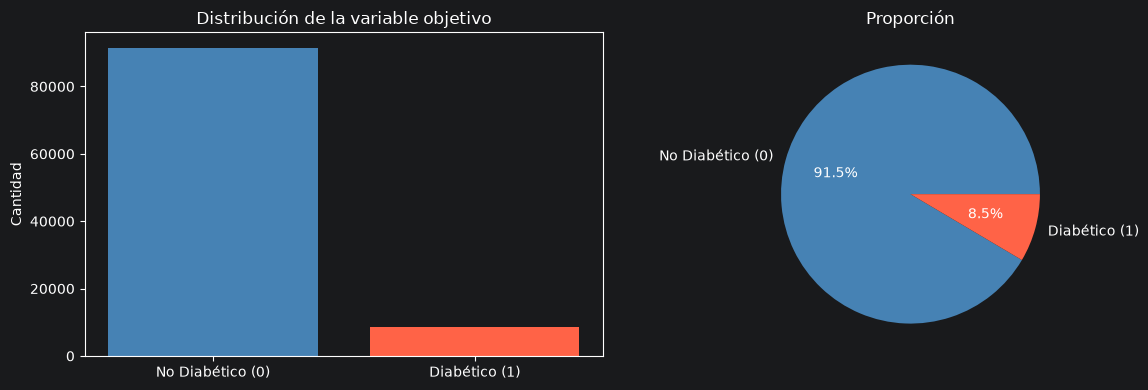

In [7]:
target_dist = df.group_by('diabetes').agg(pl.len().alias('count')).sort('diabetes')
print(target_dist)

counts = target_dist['count'].to_list()
labels = ['No Diabético (0)', 'Diabético (1)']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, counts, color=['steelblue', 'tomato'])
axes[0].set_title('Distribución de la variable objetivo')
axes[0].set_ylabel('Cantidad')
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Proporción')
plt.tight_layout()
plt.show()

### 1.5 Distribución de variables numéricas


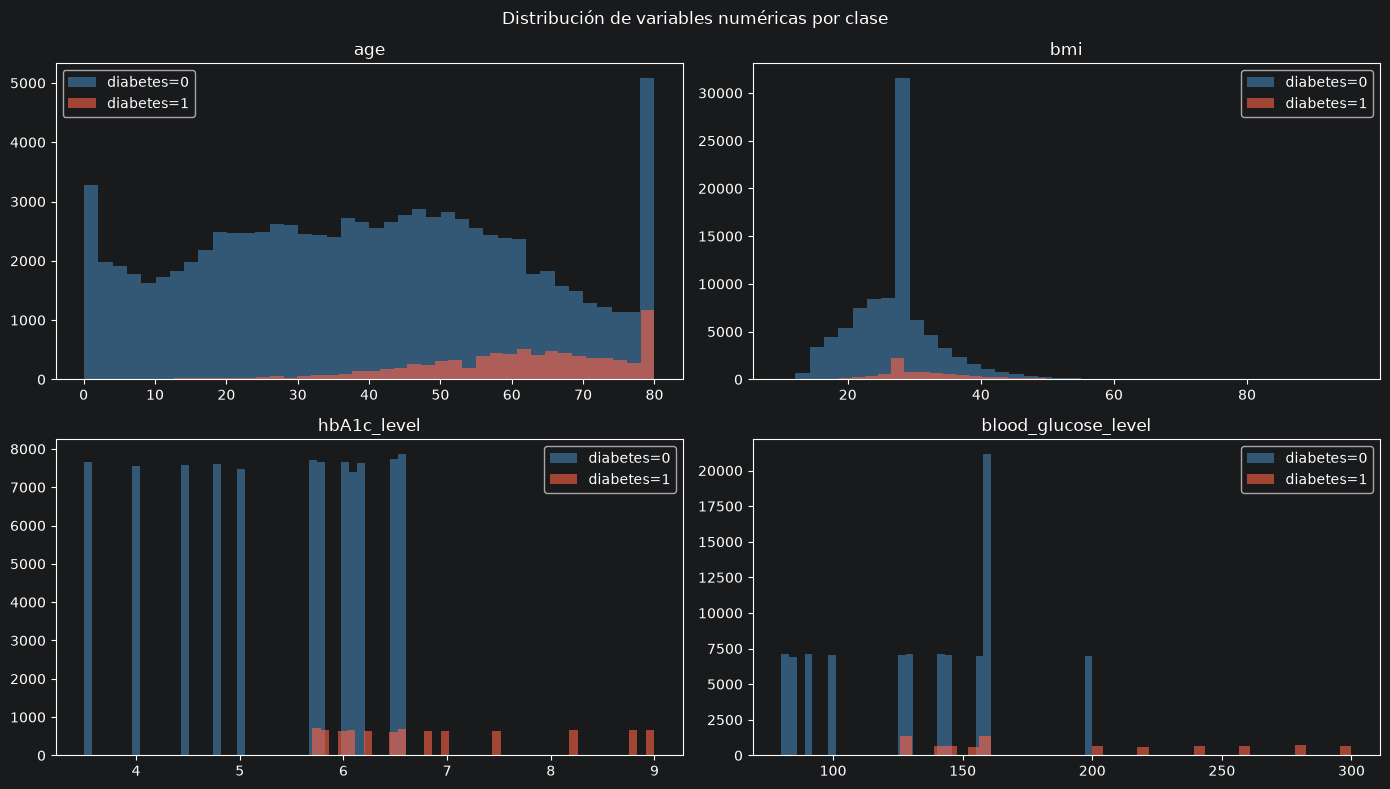

In [8]:
# Se usan arrays de numpy directamente desde Polars, sin necesidad de pyarrow
num_cols = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flat, num_cols):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        vals = df.filter(pl.col('diabetes') == label)[col].to_numpy()
        ax.hist(vals, bins=40, alpha=0.6, color=color, label=f'diabetes={label}')
    ax.set_title(col)
    ax.legend()
plt.suptitle('Distribución de variables numéricas por clase')
plt.tight_layout()
plt.show()

### 1.6 Distribución de variables categóricas


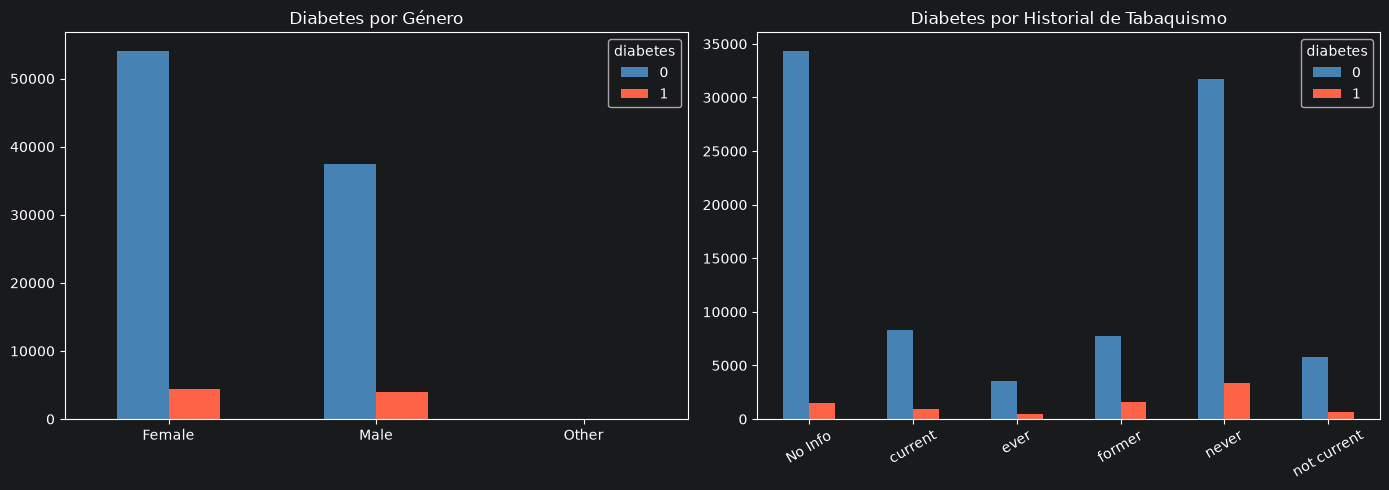

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Género — extraído con Polars, pivoteado con pandas sin pyarrow
gender_dist = (
    df.group_by(['gender', 'diabetes'])
    .agg(pl.len().alias('count'))
    .sort(['gender', 'diabetes'])
)
genders  = gender_dist['gender'].to_list()
diab_lbl = gender_dist['diabetes'].to_list()
counts_g = gender_dist['count'].to_list()
gd = pd.DataFrame({'gender': genders, 'diabetes': diab_lbl, 'count': counts_g})
gd.pivot(index='gender', columns='diabetes', values='count').fillna(0).plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato']
)
axes[0].set_title('Diabetes por Género')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Tabaquismo
smoke_dist = (
    df.group_by(['smoking_history', 'diabetes'])
    .agg(pl.len().alias('count'))
    .sort(['smoking_history', 'diabetes'])
)
sd = pd.DataFrame({
    'smoking_history': smoke_dist['smoking_history'].to_list(),
    'diabetes': smoke_dist['diabetes'].to_list(),
    'count': smoke_dist['count'].to_list()
})
sd.pivot(index='smoking_history', columns='diabetes', values='count').fillna(0).plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato']
)
axes[1].set_title('Diabetes por Historial de Tabaquismo')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 1.7 Análisis de correlaciones


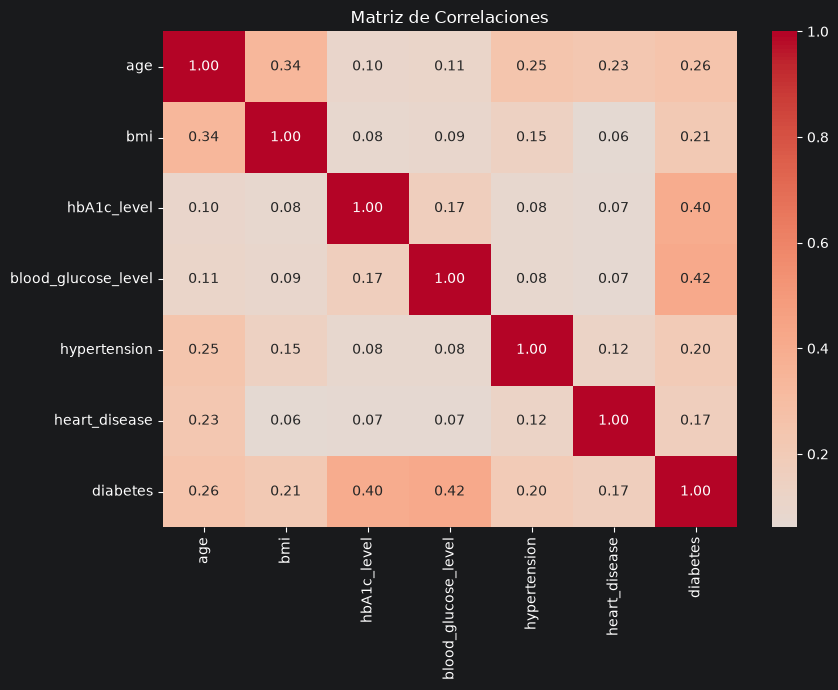

In [10]:
num_df = df.select(['age', 'bmi', 'hbA1c_level', 'blood_glucose_level',
                    'hypertension', 'heart_disease', 'diabetes'])

# Construir matriz de correlación con numpy, sin pyarrow
arr = np.column_stack([num_df[c].to_numpy() for c in num_df.columns])
corr_matrix = pd.DataFrame(np.corrcoef(arr.T), columns=num_df.columns, index=num_df.columns)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlaciones')
plt.tight_layout()
plt.show()

In [11]:
# Correlación con el target usando Polars nativo
corr_with_target = num_df.select([
    pl.corr(col, 'diabetes').alias(col)
    for col in ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'hypertension', 'heart_disease']
])
print("Correlación con diabetes:")
corr_with_target

Correlación con diabetes:


age,bmi,hbA1c_level,blood_glucose_level,hypertension,heart_disease
f64,f64,f64,f64,f64,f64
0.258008,0.214357,0.40066,0.419558,0.197823,0.171727


### 1.8 Análisis por grupo (group_by con Polars)

In [12]:
age_analysis = (
    df
    .with_columns(
        pl.when(pl.col('age') < 30).then(pl.lit('<30'))
        .when(pl.col('age') < 45).then(pl.lit('30-44'))
        .when(pl.col('age') < 60).then(pl.lit('45-59'))
        .otherwise(pl.lit('60+'))
        .alias('age_group')
    )
    .group_by('age_group')
    .agg([
        pl.len().alias('total'),
        pl.col('diabetes').mean().alias('diabetes_rate'),
        pl.col('bmi').mean().alias('avg_bmi'),
        pl.col('hbA1c_level').mean().alias('avg_hbA1c')
    ])
    .sort('age_group')
)
print(age_analysis)

shape: (4, 5)
┌───────────┬───────┬───────────────┬───────────┬───────────┐
│ age_group ┆ total ┆ diabetes_rate ┆ avg_bmi   ┆ avg_hbA1c │
│ ---       ┆ ---   ┆ ---           ┆ ---       ┆ ---       │
│ str       ┆ u32   ┆ f64           ┆ f64       ┆ f64       │
╞═══════════╪═══════╪═══════════════╪═══════════╪═══════════╡
│ 30-44     ┆ 19973 ┆ 0.041706      ┆ 28.988456 ┆ 5.462589  │
│ 45-59     ┆ 22537 ┆ 0.109198      ┆ 29.479025 ┆ 5.573621  │
│ 60+       ┆ 25055 ┆ 0.196847      ┆ 28.548637 ┆ 5.694089  │
│ <30       ┆ 32435 ┆ 0.008448      ┆ 23.845703 ┆ 5.406761  │
└───────────┴───────┴───────────────┴───────────┴───────────┘


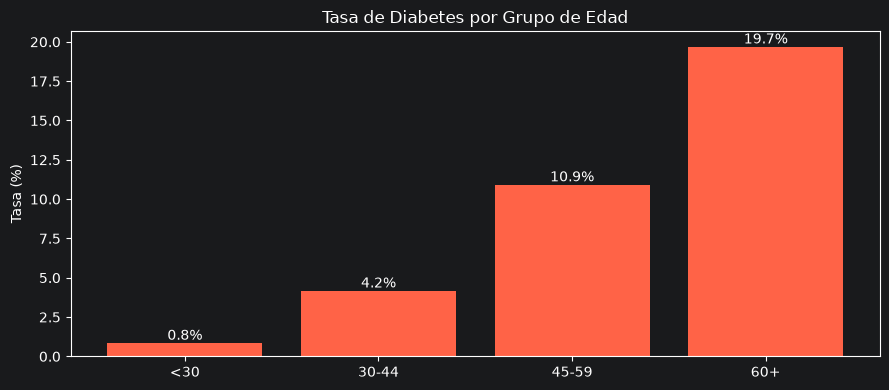

In [13]:
age_groups = age_analysis['age_group'].to_list()
diab_rates = age_analysis['diabetes_rate'].to_list()

# Ordenar manualmente
order = {'<30': 0, '30-44': 1, '45-59': 2, '60+': 3}
paired = sorted(zip(age_groups, diab_rates), key=lambda x: order.get(x[0], 99))
age_groups_s, diab_rates_s = zip(*paired)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(age_groups_s, [r * 100 for r in diab_rates_s], color='tomato')
ax.bar_label(bars, fmt='%.1f%%')
ax.set_title('Tasa de Diabetes por Grupo de Edad')
ax.set_ylabel('Tasa (%)')
plt.tight_layout()
plt.show()

## Parte 2: Ingeniería de Características con Polars
Pipeline con filtrado, transformación, manejo de nulos, nuevas características, join y group_by.

In [14]:
# Tabla auxiliar para el join: tasa de diabetes por estado
location_stats = (
    df
    .group_by('location')
    .agg(pl.col('diabetes').mean().alias('location_diabetes_rate'))
)
location_stats.head(5)

location,location_diabetes_rate
str,f64
"""Georgia""",0.084479
"""New Mexico""",0.090507
"""Nebraska""",0.085868
"""California""",0.081067
"""Minnesota""",0.084438


In [15]:
def polars_feature_pipeline(data: pl.DataFrame, loc_stats: pl.DataFrame) -> pl.DataFrame:
    return (
        data
        # Filtrado
        .filter(pl.col('gender').is_in(['Male', 'Female']))
        # Manejo de nulos
        .with_columns([
            pl.col('bmi').fill_null(pl.col('bmi').mean()),
            pl.col('hbA1c_level').fill_null(pl.col('hbA1c_level').mean()),
            pl.col('blood_glucose_level').fill_null(pl.col('blood_glucose_level').mean()),
        ])
        # Encoding categórico
        .with_columns([
            pl.when(pl.col('gender') == 'Male').then(1).otherwise(0).alias('gender_enc'),
            pl.col('smoking_history').replace(
                {'never': 0, 'No Info': 0, 'not current': 1, 'former': 2, 'ever': 2, 'current': 3}
            ).cast(pl.Int32).alias('smoking_enc'),
        ])
        # Nuevas características
        .with_columns([
            (pl.col('bmi') * pl.col('hbA1c_level') / 10).alias('metabolic_risk'),
            pl.when(pl.col('bmi') < 18.5).then(pl.lit('underweight'))
              .when(pl.col('bmi') < 25).then(pl.lit('normal'))
              .when(pl.col('bmi') < 30).then(pl.lit('overweight'))
              .otherwise(pl.lit('obese'))
              .alias('bmi_category'),
            (pl.col('blood_glucose_level') > 140).cast(pl.Int32).alias('high_glucose'),
            (pl.col('hbA1c_level') >= 6.5).cast(pl.Int32).alias('hbA1c_diabetic_range'),
            (pl.col('hypertension') + pl.col('heart_disease')).alias('comorbidity_score'),
            pl.when(pl.col('age') < 30).then(0)
              .when(pl.col('age') < 45).then(1)
              .when(pl.col('age') < 60).then(2)
              .otherwise(3)
              .alias('age_group_enc'),
        ])
        .with_columns(
            pl.col('bmi_category').replace(
                {'underweight': 0, 'normal': 1, 'overweight': 2, 'obese': 3}
            ).cast(pl.Int32).alias('bmi_cat_enc')
        )
        # Join con estadísticas por estado
        .join(loc_stats, on='location', how='left')
    )

df_feat = polars_feature_pipeline(df, location_stats)
print(f"Shape después del pipeline: {df_feat.shape}")
df_feat.head(3)

Shape después del pipeline: (99982, 26)


year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,gender_enc,smoking_enc,metabolic_risk,bmi_category,high_glucose,hbA1c_diabetic_range,comorbidity_score,age_group_enc,bmi_cat_enc,location_diabetes_rate
i64,str,f64,str,i64,i64,i64,i64,i64,i64,i64,str,f64,f64,f64,i64,i32,i32,f64,str,i32,i32,i64,i32,i32,f64
2020,"""Female""",32.0,"""Alabama""",0,0,0,0,1,0,0,"""never""",27.32,5.0,100.0,0,0,0,13.66,"""overweight""",0,0,0,1,2,0.085953
2015,"""Female""",29.0,"""Alabama""",0,1,0,0,0,0,0,"""never""",19.95,5.0,90.0,0,0,0,9.975,"""normal""",0,0,0,0,1,0.085953
2015,"""Male""",18.0,"""Alabama""",0,0,0,0,1,0,0,"""never""",23.76,4.8,160.0,0,1,0,11.4048,"""normal""",1,0,0,0,1,0.085953


In [16]:
# Agregación group_by: resumen por categoría de BMI
bmi_summary = (
    df_feat
    .group_by('bmi_category')
    .agg([
        pl.len().alias('n'),
        pl.col('diabetes').mean().alias('diabetes_rate'),
        pl.col('metabolic_risk').mean().alias('avg_metabolic_risk'),
        pl.col('hbA1c_level').mean().alias('avg_hbA1c')
    ])
    .sort('diabetes_rate', descending=True)
)
print(bmi_summary)

shape: (4, 5)
┌──────────────┬───────┬───────────────┬────────────────────┬───────────┐
│ bmi_category ┆ n     ┆ diabetes_rate ┆ avg_metabolic_risk ┆ avg_hbA1c │
│ ---          ┆ ---   ┆ ---           ┆ ---                ┆ ---       │
│ str          ┆ u32   ┆ f64           ┆ f64                ┆ f64       │
╞══════════════╪═══════╪═══════════════╪════════════════════╪═══════════╡
│ obese        ┆ 23530 ┆ 0.179898      ┆ 20.53555           ┆ 5.670472  │
│ overweight   ┆ 45744 ┆ 0.073015      ┆ 15.071981          ┆ 5.510119  │
│ normal       ┆ 22216 ┆ 0.038846      ┆ 12.067649          ┆ 5.455226  │
│ underweight  ┆ 8492  ┆ 0.007537      ┆ 8.836522           ┆ 5.41439   │
└──────────────┴───────┴───────────────┴────────────────────┴───────────┘


In [17]:
FEATURE_COLS = [
    'age', 'gender_enc', 'smoking_enc', 'bmi', 'hbA1c_level', 'blood_glucose_level',
    'hypertension', 'heart_disease', 'metabolic_risk', 'high_glucose',
    'hbA1c_diabetic_range', 'comorbidity_score', 'age_group_enc', 'bmi_cat_enc',
    'location_diabetes_rate',
    'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other'
]
TARGET_COL = 'diabetes'

df_ml = df_feat.select(FEATURE_COLS + [TARGET_COL]).drop_nulls()
print(f"Dataset para ML: {df_ml.shape}")

Dataset para ML: (99982, 21)


## Parte 3: Machine Learning

In [18]:
X = np.column_stack([df_ml[c].to_numpy() for c in FEATURE_COLS])
y = df_ml[TARGET_COL].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Positivos — train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

Train: (79985, 20) | Test: (19997, 20)
Positivos — train: 0.085 | test: 0.085


In [19]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, scale=False):
    Xtr = X_train_sc if scale else X_tr
    Xte = X_test_sc  if scale else X_te
    t0 = time.time()
    model.fit(Xtr, y_tr)
    train_time = time.time() - t0
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    return {
        'Modelo': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'AUC-ROC': roc_auc_score(y_te, y_proba),
        'Tiempo (s)': train_time
    }, model, y_pred

### 3.1 Regresión Logística


In [20]:
lr_metrics, lr_fitted, lr_pred = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train, y_train, X_test, y_test, scale=True
)
print(lr_metrics)

{'Modelo': 'Logistic Regression', 'Accuracy': 0.964444666700005, 'F1': 0.755586112066002, 'AUC-ROC': 0.9625702702789593, 'Tiempo (s)': 0.19562101364135742}


### 3.2 Random Forest


In [21]:
rf_metrics, rf_fitted, rf_pred = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
    X_train, y_train, X_test, y_test
)
print(rf_metrics)

{'Modelo': 'Random Forest', 'Accuracy': 0.9718957843676551, 'F1': 0.8045897079276774, 'AUC-ROC': 0.968372475076274, 'Tiempo (s)': 6.285735845565796}


### 3.3 Gradient Boosting (XGBoost)


In [22]:
xgb_metrics, xgb_fitted, xgb_pred = evaluate_model(
    'XGBoost',
    xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
    ),
    X_train, y_train, X_test, y_test
)
print(xgb_metrics)

{'Modelo': 'XGBoost', 'Accuracy': 0.9726458968845327, 'F1': 0.8102670828997572, 'AUC-ROC': 0.9785219370581483, 'Tiempo (s)': 3.9584221839904785}


### 3.4 LightGBM

In [23]:
lgbm_metrics, lgbm_fitted, lgbm_pred = evaluate_model(
    'LightGBM',
    lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=63,
                       random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    X_train, y_train, X_test, y_test
)
print(lgbm_metrics)

{'Modelo': 'LightGBM', 'Accuracy': 0.9719957993699054, 'F1': 0.8066298342541437, 'AUC-ROC': 0.9772443891476906, 'Tiempo (s)': 9.36592173576355}


### 3.5 Comparación de modelos

In [24]:
results_df = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics, lgbm_metrics])
results_df = results_df.set_index('Modelo').sort_values('AUC-ROC', ascending=False)
print(results_df.round(4))

                     Accuracy      F1  AUC-ROC  Tiempo (s)
Modelo                                                    
XGBoost                0.9726  0.8103   0.9785      3.9584
LightGBM               0.9720  0.8066   0.9772      9.3659
Random Forest          0.9719  0.8046   0.9684      6.2857
Logistic Regression    0.9644  0.7556   0.9626      0.1956


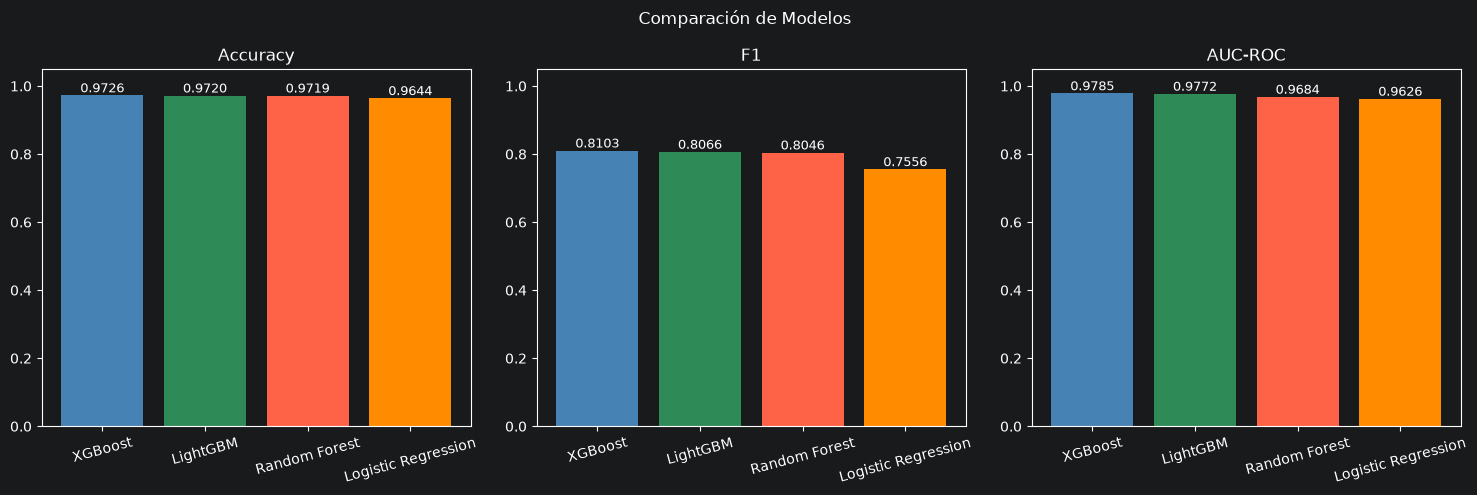

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['steelblue', 'seagreen', 'tomato', 'darkorange']
for ax, metric in zip(axes, ['Accuracy', 'F1', 'AUC-ROC']):
    bars = ax.bar(results_df.index, results_df[metric], color=colors)
    ax.bar_label(bars, fmt='%.4f', fontsize=9)
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Comparación de Modelos')
plt.tight_layout()
plt.show()

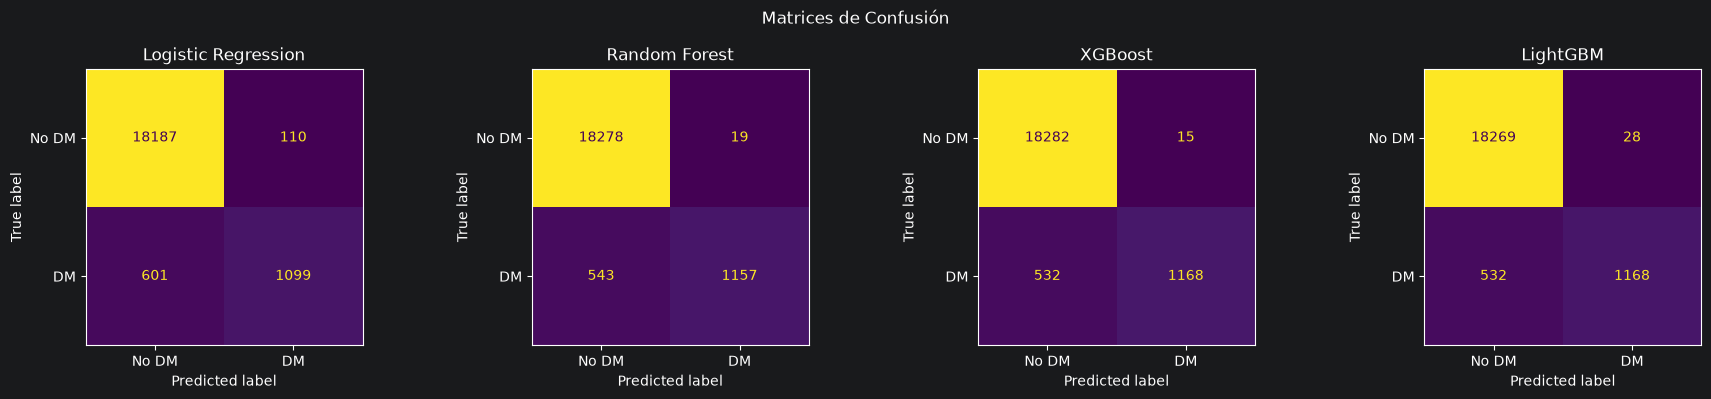

In [26]:
# Matrices de confusión
models_preds = [
    ('Logistic Regression', lr_pred),
    ('Random Forest', rf_pred),
    ('XGBoost', xgb_pred),
    ('LightGBM', lgbm_pred)
]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No DM', 'DM']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.suptitle('Matrices de Confusión')
plt.tight_layout()
plt.show()

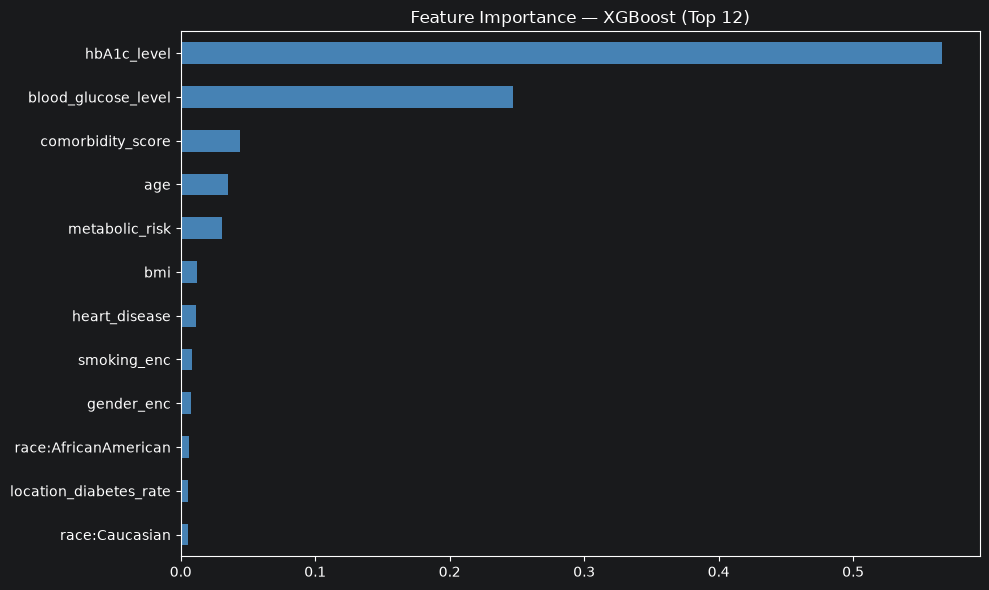

In [27]:
# Feature importance — XGBoost
fi = pd.Series(xgb_fitted.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True).tail(12)
fi.plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Feature Importance — XGBoost (Top 12)')
plt.tight_layout()
plt.show()